In [1]:
import pandas as pd 
import numpy as np 


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

import matplotlib.pyplot as plt

In [2]:
# https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python?utm_source=chatgpt.com

In [3]:
df = pd.read_csv("Mall_Customers.csv")

In [4]:
df.sample(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
38,39,Female,36,37,26
37,38,Female,30,34,73
101,102,Female,49,62,48
117,118,Female,49,65,59
94,95,Female,32,60,42
41,42,Male,24,38,92
186,187,Female,54,101,24
84,85,Female,21,54,57
128,129,Male,59,71,11
45,46,Female,24,39,65


In [5]:
# Data Preprocessing

In [6]:
df["Gender"] = df["Gender"].map({"Male" : 1 , "Female" : 0})

In [7]:
df.drop(columns = ["CustomerID"] , axis = 1 , inplace = True)

In [8]:
df.sample(9)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
39,0,20,37,75
86,0,55,57,58
175,0,30,88,86
50,0,49,42,52
195,0,35,120,79
170,1,40,87,13
62,0,67,47,52
88,0,34,58,60
187,1,28,101,68


In [9]:
# Applying K meanms 

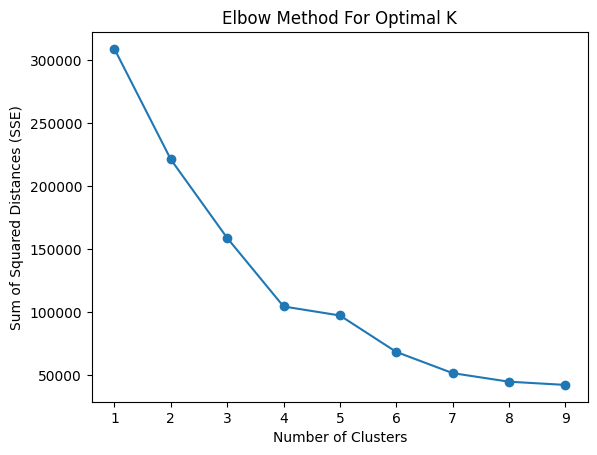

In [10]:
sse = []
k_range = range(1,10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    sse.append(kmeans.inertia_)
    
# Plot the elbow curve
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances (SSE)')
plt.title('Elbow Method For Optimal K')
plt.show()

In [11]:
kmeans = KMeans(n_clusters= 4 , random_state = 42)

In [12]:
df["Clusters"] = kmeans.fit_predict(df)

In [13]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,0
3,0,23,16,77,2
4,0,31,17,40,0
...,...,...,...,...,...
195,0,35,120,79,1
196,0,45,126,28,3
197,1,32,126,74,1
198,1,32,137,18,3


In [14]:
df["Clusters"].value_counts()

Clusters
0    95
1    39
3    38
2    28
Name: count, dtype: int64

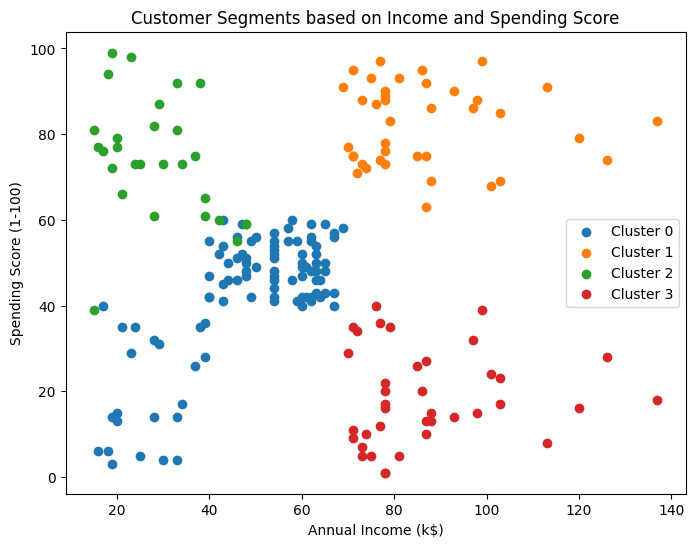

In [15]:
plt.figure(figsize=(8,6))

# Plot each cluster with different color
for cluster in range(4):
    plt.scatter(
        df[df['Clusters'] == cluster]['Annual Income (k$)'],
        df[df['Clusters'] == cluster]['Spending Score (1-100)'],
        label=f'Cluster {cluster}'
    )

plt.title('Customer Segments based on Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


In [16]:
# Now Genarating CLuster NAMes

In [17]:
# Define your cluster labels
cluster_labels = {
    0: "Moderate Income – Average Spending",
    1: "High Income – High Spending (Luxury Spenders)",
    2: "Low Income – High Spending (Target Customers)",
    3: "High Income – Low Spending (Careful Spenders)"
}

# Map cluster numbers to names
df['Segment'] = df['Clusters'].map(cluster_labels)

# Display first few rows
print(df.head())


   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Clusters  \
0       1   19                  15                      39         2   
1       1   21                  15                      81         2   
2       0   20                  16                       6         0   
3       0   23                  16                      77         2   
4       0   31                  17                      40         0   

                                         Segment  
0  Low Income – High Spending (Target Customers)  
1  Low Income – High Spending (Target Customers)  
2             Moderate Income – Average Spending  
3  Low Income – High Spending (Target Customers)  
4             Moderate Income – Average Spending  


In [18]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters,Segment
0,1,19,15,39,2,Low Income – High Spending (Target Customers)
1,1,21,15,81,2,Low Income – High Spending (Target Customers)
2,0,20,16,6,0,Moderate Income – Average Spending
3,0,23,16,77,2,Low Income – High Spending (Target Customers)
4,0,31,17,40,0,Moderate Income – Average Spending
...,...,...,...,...,...,...
195,0,35,120,79,1,High Income – High Spending (Luxury Spenders)
196,0,45,126,28,3,High Income – Low Spending (Careful Spenders)
197,1,32,126,74,1,High Income – High Spending (Luxury Spenders)
198,1,32,137,18,3,High Income – Low Spending (Careful Spenders)


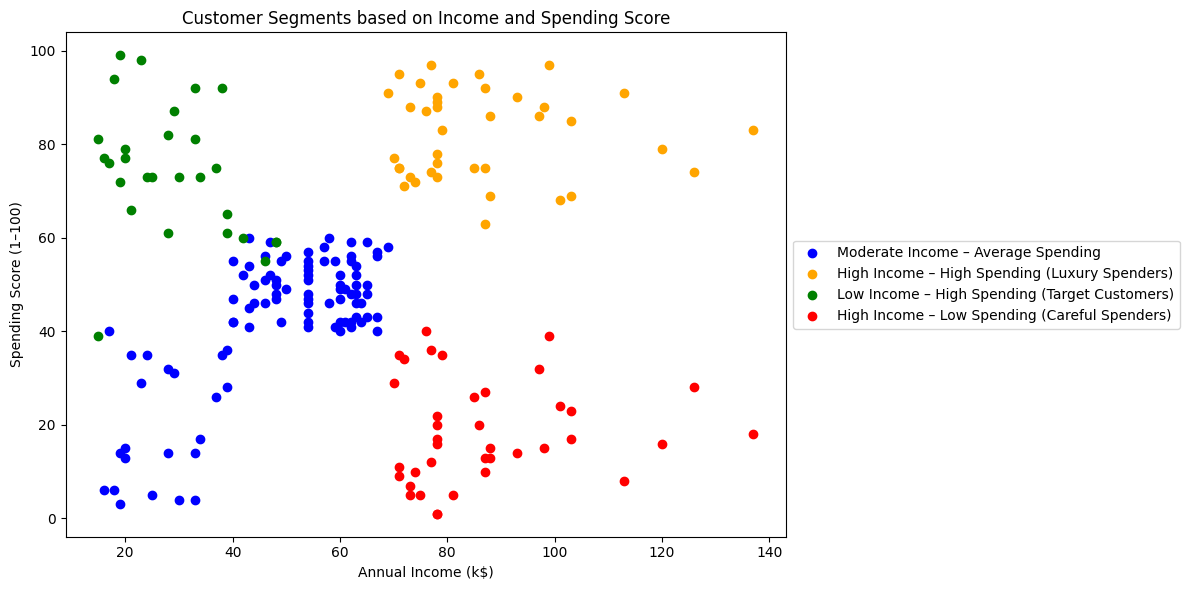

In [29]:
plt.figure(figsize=(12,6))
colors = ['blue', 'orange', 'green', 'red']

for cluster, color in zip(range(4), colors):
    plt.scatter(
        df[df['Clusters'] == cluster]['Annual Income (k$)'],
        df[df['Clusters'] == cluster]['Spending Score (1-100)'],
        c=color, label=cluster_labels[cluster]
    )

plt.title('Customer Segments based on Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')

# Place legend on right side, centered vertically
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()  # ensures nothing is cut off
plt.show()


In [ ]:
# 6. Evaluate Kmeans

In [26]:
# Using silhouette score (measures how similar a point is to its own cluster compared to other clusters)
features = df[['Gender','Age','Annual Income (k$)','Spending Score (1-100)']]

silhouette_avg = silhouette_score(features, df['Clusters'])
print(f'Silhouette Score: {silhouette_avg:.2f}')

Silhouette Score: 0.41


In [ ]:
# 7. Save and Load trained Kmeans


In [30]:
import pickle
pickle.dump(kmeans , open("k_means.pkl","wb"))

In [33]:
kmeans = pickle.load(open("k_means.pkl" , "rb"))

In [34]:
kmeans

KMeans(n_clusters=4, random_state=42)

In [ ]:
# 8. Real-time Customer Segmentation Function

In [35]:
# Define your cluster labels
cluster_labels = {
    0: "Moderate Income – Average Spending",
    1: "High Income – High Spending (Luxury Spenders)",
    2: "Low Income – High Spending (Target Customers)",
    3: "High Income – Low Spending (Careful Spenders)"
}


# Function to predict customer segment
def predict_customer_segment(gender, age, income, spending_score):
    # Prepare input as a NumPy array
    new_data = np.array([[gender, age, income, spending_score]])
    
    # Predict cluster
    cluster = kmeans.predict(new_data)[0]
    
    # Map to segment
    segment = cluster_labels.get(cluster, "Unknown Segment")
    
    # Print result
    print(f"Predicted Cluster: {cluster}")
    print(f"Customer Segment: {segment}")


In [37]:
predict_customer_segment(gender=1, age=28, income=50, spending_score=90)

Predicted Cluster: 2
Customer Segment: Low Income – High Spending (Target Customers)


C:\Users\sajan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [39]:
predict_customer_segment(gender=0, age=28, income=1000, spending_score=60)

Predicted Cluster: 1
Customer Segment: High Income – High Spending (Luxury Spenders)


C:\Users\sajan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
